生成内部点数: 1623
生成边界点数: 100
Patch 数量: 22
预测点数: 1623


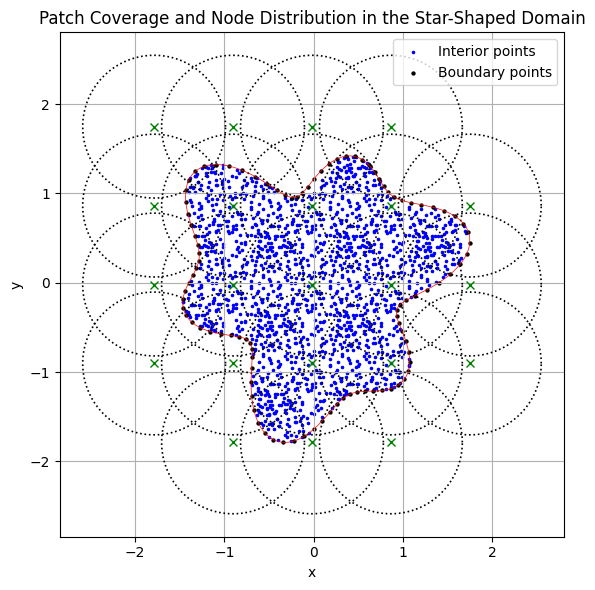

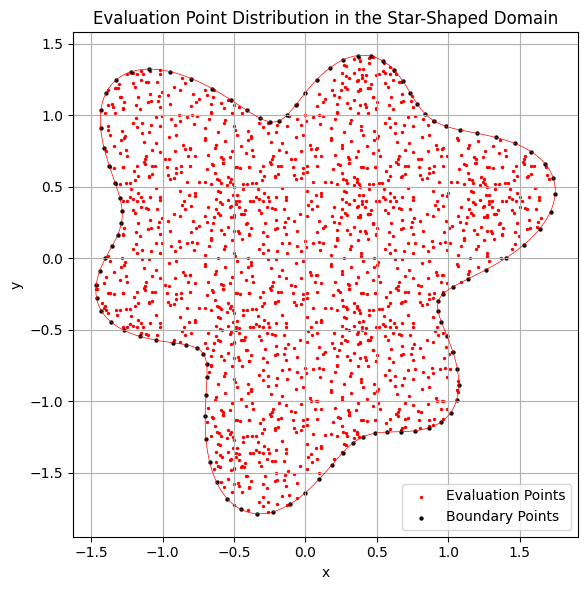

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()

    plt.show()


# ============================
# Example usage
# ============================
if __name__ == "__main__":
    # parameters (same defaults as your MATLAB example)
    N_patch_grid = 5
    N_local_per_patch = 200
    N_boundary = 100
    R_ptch = 0.8
    mode = "c-rbf-pum"  # or "ls-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode
    )

    print("生成内部点数:", X_inner.shape[0])
    print("生成边界点数:", X_boundary.shape[0])
    print("Patch 数量:", ptch['C'].shape[0])
    print("预测点数:", grid_eval.shape[0])

    # 绘图
    plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve)

Run Q=1, N_local_per_patch=50
h = 1.664e-01, max abs error = 3.823e-03
Run Q=2, N_local_per_patch=100
h = 1.257e-01, max abs error = 3.413e-04
Run Q=3, N_local_per_patch=150
h = 9.066e-02, max abs error = 1.103e-04
Run Q=4, N_local_per_patch=200
h = 7.872e-02, max abs error = 2.770e-05
Run Q=5, N_local_per_patch=250
h = 7.423e-02, max abs error = 1.924e-05
slope = 6.196873, bias = -2.318598


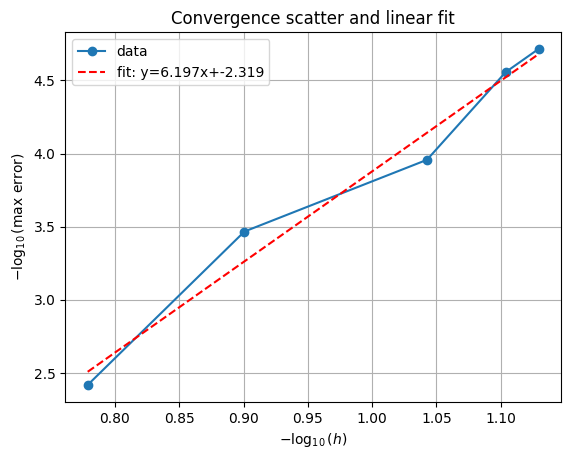

In [2]:

import numpy as np
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve, lsqr
import matplotlib.pyplot as plt

# -----------------------
# fill_distance (efficient)
# -----------------------
def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

# -----------------------
# rbf_fd_solve_poisson (scipy version)
# -----------------------
def rbf_fd_solve_poisson(X, Yin, Yb, f_func, g_func, reg=1e-12, eps=1.0, K=100):
    """
    X: (N,2) ndarray
    Yin: (M1,2)
    Yb: (M2,2)
    returns: UY (M,) at Y = [Yin;Yb]
    """
    X = np.asarray(X)
    Yin = np.asarray(Yin)
    Yb = np.asarray(Yb)
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack([Yin, Yb]) if M > 0 else np.empty((0, X.shape[1]))

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)

    def phi_gauss(eps, r):
        return np.exp(-(eps**2) * (r**2))
    def laplace_phi_gauss(eps, r):
        return phi_gauss(eps, r) * (4.0 * eps**4 * (r**2) - 4.0 * eps**2)

    L = lil_matrix((M, N), dtype=np.float64)

    RHS_interior = f_func(Yin[:, 0], Yin[:, 1]) if M1 > 0 else np.empty((0,))
    RHS_boundary = g_func(Yb[:, 0], Yb[:, 1]) if M2 > 0 else np.empty((0,))
    RHS = np.concatenate([RHS_interior, RHS_boundary]) if M > 0 else np.empty((0,))

    # interior rows
    for i in range(M1):
        inds = idx[i, :]
        Z = X[inds, :]
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean')
        Phi_jj = phi_gauss(eps, dist_ZZ)
        Lap_phi = laplace_phi_gauss(eps, dist[i, :])
        A = Phi_jj + reg * np.eye(K)
        
        R = cholesky(A, lower=False, check_finite=False)
        z = np.linalg.solve(R.T, Lap_phi)
        w = np.linalg.solve(R, z)
        # print(np.sum(w)) ## 对于常函数, 求导算子满足 \sum w \approx 0 
        L[i, inds] = L[i, inds] - w


    # boundary rows
    for jj in range(M2):
        row = M1 + jj
        inds = idx[row, :]
        Z = X[inds, :]
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean')
        Phi_jj = phi_gauss(eps, dist_ZZ)
        Phi_xj = phi_gauss(eps, dist[row, :])
        A = Phi_jj + reg * np.eye(K)

        R = cholesky(A, lower=False, check_finite=False)
        z = np.linalg.solve(R.T, Phi_xj)
        w = np.linalg.solve(R, z)

        L[row, inds] = L[row, inds] + w

    L_csr = L.tocsr()

    if M == N:
        try:
            UX = spsolve(L_csr, RHS)
        except Exception:
            UX = lsqr(L_csr, RHS)[0]
    else:
        UX = lsqr(L_csr, RHS)[0]

    # evaluation matrix LL -> UY
    LL = lil_matrix((M, N), dtype=np.float64)
    for i in range(M):
        inds = idx[i, :]
        Z = X[inds, :]
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean')
        Phi_jj = phi_gauss(eps,dist_ZZ)
        Phi_xj = phi_gauss(eps,dist[i, :])
        A = Phi_jj + reg * np.eye(K)
        R = cholesky(A, lower=False, check_finite=False)
        w = np.linalg.solve(R,np.linalg.solve(R.T, Phi_xj))
        LL[i, inds] = LL[i, inds] + w
    LL_csr = LL.tocsr()
    UY = LL_csr.dot(UX)
    return np.asarray(UY)

def main_experiment():
    # PDE functions (vectorized)
    u_func = lambda x, y: np.sin(x) * np.cos(y)
    f_func = lambda x, y: 2.0 * np.sin(x) * np.cos(y)
    g_func = lambda x, y: np.sin(x) * np.cos(y)

    np.random.seed(10)

    NN = [50, 100, 150, 200, 250]
    H = np.zeros(len(NN))
    E = np.zeros(len(NN))
    KK = [50, 60, 90, 120, 150]
    for qi, n_local in enumerate(NN):
        print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
        N_patch_grid = 5
        N_local_per_patch = n_local
        N_boundary = n_local
        R_ptch = 0.8
        mode = "c-rbf-pum"
        # generate points
        X_inner, X_boundary, _, _ ,_ = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

        # assemble X,Y
        X = np.vstack([X_inner, X_boundary])
        Yin = X_inner
        Yb = X_boundary
        Y = np.vstack([Yin, Yb])

        h = fill_distance(X)
        H[qi] = h
        rho = 2.2 * h
        eps = np.sqrt(1.0 / rho)
        reg = 1e-12
        K = KK[qi]

        UY = rbf_fd_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K)
        u_y_true = u_func(Y[:, 0], Y[:, 1])
        error = np.max(np.abs(UY - u_y_true))
        e = np.abs(UY - u_y_true)
        E[qi] = error
        print(f'h = {h:.3e}, max abs error = {error:.3e}')

    # # plot -log10(H) vs -log10(E)
    # plt.figure()
    # plt.plot(-np.log10(H), -np.log10(E), marker='o', linestyle='-')
    # plt.xlabel(r'$- \log_{10}(h)$')
    # plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    # plt.grid(True)
    # plt.title('Convergence scatter: -log10(h) vs -log10(error)')
    # plt.show()

    x = -np.log10(H)
    y = -np.log10(E)
    mask = np.isfinite(x) & np.isfinite(y) & (H > 0) & (E > 0)
    if np.count_nonzero(mask) >= 2:
        slope, intercept = np.polyfit(x[mask], y[mask], 1)
        print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
        # 绘图并画出拟合直线
        xx = np.linspace(x[mask].min(), x[mask].max(), 100)
        yy = slope * xx + intercept
        plt.figure()
        plt.plot(x, y, marker='o', linestyle='-', label='data')
        plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
        plt.xlabel(r'$- \log_{10}(h)$')
        plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
        plt.legend()
        plt.grid(True)
        plt.title('Convergence scatter and linear fit')
        plt.show()

if __name__ == '__main__':
    main_experiment()

$torch\  version$

In [3]:

import torch

# ===========================================================
# RBF–Gaussian
# ===========================================================
def phi_gauss(eps, r):
    return torch.exp(-(eps**2) * r**2)

def laplace_phi_gauss(eps, r):
    """ \Delta \phi(r) for Gaussian RBF """
    return phi_gauss(eps, r) * (4 * eps**4 * r**2 - 4 * eps**2)

# ===========================================================
# Fill-distance
# ===========================================================
def fill_distance(X):
    """
    X: (N,2) torch tensor
    """
    N = X.shape[0]
    h = torch.zeros(N, dtype=X.dtype, device=X.device)
    for i in range(N):
        others = torch.cat([X[:i], X[i+1:]], dim=0)
        h[i] = torch.min(torch.norm(X[i] - others, dim=1))
    return torch.max(h)

# ===========================================================
# Main RBF-FD solver (pure PyTorch)
# ===========================================================
def rbf_fd_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K):
    """
    X:  (N,2) torch tensor, RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    reg: regularization
    eps: RBF shape parameter
    K: number of neighbors
    """
    device = X.device
    dtype = X.dtype

    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2

    # Combine evaluation points
    Y = torch.cat([Yin, Yb], dim=0)

    # Compute distance to all source points
    dists = torch.cdist(Y, X)  # (M, N)

    # Find K nearest neighbors
    _, idx = torch.topk(-dists, K, dim=1)  # largest negative = smallest distance
    dist_K = torch.gather(dists, 1, idx)   # (M, K)

    # Construct dense L matrix
    L = torch.zeros(M, N, dtype=dtype, device=device)

    # Construct RHS
    RHS = torch.cat([f_func(Yin[:, 0], Yin[:, 1]),
                     g_func(Yb[:, 0], Yb[:, 1])], dim=0)

    # ===========================================================
    # Interior points: Laplacian weights
    # ===========================================================
    for i in range(M1):
        idx_local = idx[i]             # (K,)
        Z = X[idx_local]               # (K,2)
        # Distance matrices
        diff = Z[:, None, :] - Z[None, :, :]  # (K,K,2)
        dist_ZZ = torch.norm(diff, dim=2)     # (K,K)
        Phi_jj = phi_gauss(eps, dist_ZZ)      # (K,K)
        Laplace_xj = laplace_phi_gauss(eps, dist_K[i])  # (K,)
        # Solve local linear system
        A = Phi_jj + reg * torch.eye(K, dtype=dtype, device=device)
        R = torch.linalg.cholesky(A)
        # print(Laplace_xj.shape, R.shape)
        w = torch.cholesky_solve(Laplace_xj.unsqueeze(-1), R).squeeze(-1) # 处理的就是 R^{-T} R^{-1} b
        # Assign to L
        L[i, idx_local] = -w

    # ===========================================================
    # Boundary points: φ weights
    # ===========================================================
    for j in range(M2):
        row = M1 + j
        idx_local = idx[row]
        Z = X[idx_local]
        diff = Z[:, None, :] - Z[None, :, :]
        dist_ZZ = torch.norm(diff, dim=2)
        Phi_jj = phi_gauss(eps, dist_ZZ)
        Phi_xj = phi_gauss(eps, dist_K[row])
        # Solve local system
        A = Phi_jj + reg * torch.eye(K, dtype=dtype, device=device)
        R = torch.linalg.cholesky(A)
        w = torch.cholesky_solve(Phi_xj.unsqueeze(-1), R).squeeze(-1)
        # Assign to L
        L[row, idx_local] = w

    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = torch.linalg.solve(L, RHS)

    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    UY = torch.zeros(M, dtype=dtype, device=device)
    LL = torch.zeros(M, N, dtype=dtype, device=device)
    for i in range(M):
        idx_local = idx[i]
        Z = X[idx_local]
        diff = Z[:, None, :] - Z[None, :, :]
        dist_ZZ = torch.norm(diff, dim=2)
        Phi_jj = phi_gauss(eps, dist_ZZ)
        Phi_xj = phi_gauss(eps, dist_K[i])
        A = Phi_jj + reg * torch.eye(K, dtype=dtype, device=device)
        R = torch.linalg.cholesky(A)
        w = torch.cholesky_solve(Phi_xj.unsqueeze(-1), R).squeeze(-1)
        LL[i,idx_local] = w
    UY = LL @ U 
    return UY



<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_24446/1129478268.py:10: SyntaxWarning: invalid escape sequence '\D'
  """ \Delta \phi(r) for Gaussian RBF """


Max absolute error:, 5.5623e-04
L2 error: tensor(0.0003, dtype=torch.float64)


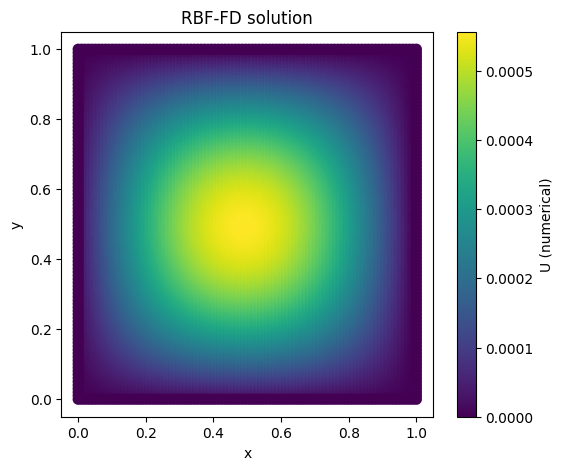

In [4]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Define exact solution and RHS
# ----------------------------
def u_exact(x, y):
    return torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

def f_func(x, y):
    return 2 * (torch.pi ** 2) * torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

def g_func(x, y):
    return u_exact(x, y)

# ----------------------------
# Generate source points X (RBF centers)
# ----------------------------
def generate_grid_points(nx, ny, device):
    x = torch.linspace(0, 1, nx, device=device)
    y = torch.linspace(0, 1, ny, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    pts = torch.stack([X.flatten(), Y.flatten()], dim=1)
    return pts

device = 'cpu'
dtype = torch.float64
# ----------------------------
# square grid of points
# ----------------------------
nx, ny = 100, 100
X = generate_grid_points(nx, ny, device=device).to(dtype=dtype)

# ----------------------------
# Interior and boundary points
# ----------------------------
eps = 1
reg = 1e-12
K = 25  # nearest neighbors

# Interior points: exclude boundary
mask_interior = (X[:,0] > 0) & (X[:,0] < 1) & (X[:,1] > 0) & (X[:,1] < 1)
Yin = X[mask_interior]

# Boundary points
mask_boundary = ~mask_interior
Yb = X[mask_boundary]

# ----------------------------
# Solve Poisson using RBF-FD
# ----------------------------
UY = rbf_fd_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K)

# ----------------------------
# Compare with exact solution
# ----------------------------
Y_all = torch.cat([Yin, Yb], dim=0)
U_exact = u_exact(Y_all[:,0], Y_all[:,1])

error = torch.abs(UY - U_exact)
print(f"Max absolute error:, {error.max().item():.4e}")
print("L2 error:", torch.norm(error).item() / torch.sqrt(torch.tensor(len(UY), dtype=dtype)))

# ----------------------------
# Plot numerical solution
# ----------------------------
plt.figure(figsize=(6,5))
plt.scatter(Y_all[:,0], Y_all[:,1], c= (UY-U_exact), cmap='viridis', s=50)
plt.colorbar(label='U (numerical)')
plt.title('RBF-FD solution')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


h = 7.423e-02, max abs error = 1.739e-05
L2 error: tensor(6.3010e-06, dtype=torch.float64)


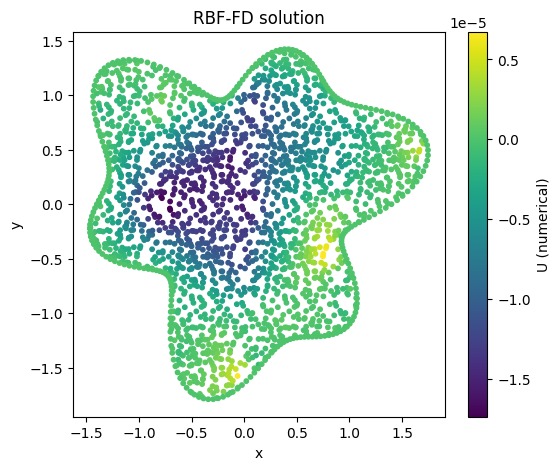

In [5]:
# ----------------------------
# star domain points
# ----------------------------
u_func = lambda x, y: torch.sin(x) * torch.cos(y)
f_func = lambda x, y: 2.0 * torch.sin(x) * torch.cos(y)
g_func = lambda x, y: torch.sin(x) * torch.cos(y)

np.random.seed(10)
N_patch_grid = 5
N_local_per_patch = 250
N_boundary = 250
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

# assemble X,Y
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])

X = torch.tensor(X, dtype=torch.float64).to(device)
Yin = torch.tensor(Yin, dtype=torch.float64).to(device)
Yb = torch.tensor(Yb, dtype=torch.float64).to(device)
Y = torch.tensor(Y, dtype=torch.float64).to(device)
# ----------------------------
# Solve Poisson using RBF-FD
# ----------------------------
h = fill_distance(X)
rho = 2.2 * h
eps = torch.sqrt(1.0 / rho)
reg = 1e-12
K = 150

UY = rbf_fd_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K)
u_y_true = u_func(Y[:, 0], Y[:, 1])
error = torch.abs(UY - u_y_true)

print(f'h = {h:.3e}, max abs error = {error.max().item():.3e}')
print("L2 error:", torch.norm(error).item() / torch.sqrt(torch.tensor(len(UY), dtype=dtype)))

# ----------------------------
# Plot numerical solution
# ----------------------------
plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = (UY - u_y_true), cmap='viridis', s=10)
plt.colorbar(label='U (numerical)')
plt.title('RBF-FD solution')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


L infinty error in u: 2.388e-02
Relative L2 error in u: 5.831e-03


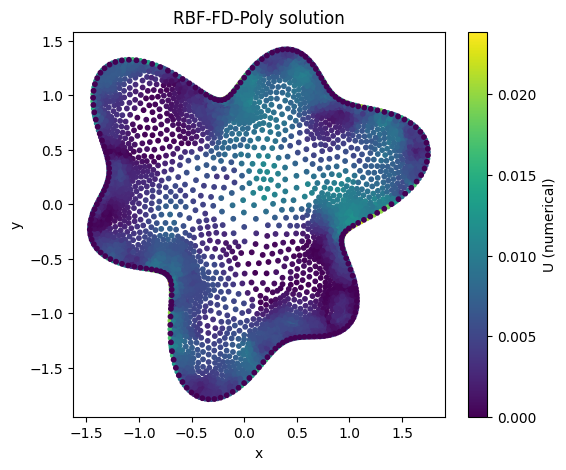

In [ ]:


import torch
import scipy
from scipy.io import loadmat
import numpy as np
import time
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

# ===========================================================
# RBF–Gaussian
# ===========================================================
def phi_gauss(eps, r): # rbf
    return torch.exp(-(eps**2) * r**2)

def laplace_phi_gauss(eps, r): # 2d Laplacian rbf derivative
    return phi_gauss(eps, r) * (4 * eps**4 * r**2 - 4 * eps**2)

# ===========================================================
# Fill-distance
# ===========================================================
def fill_distance(X):
    """
    X: (N,2) torch tensor
    """
    N = X.shape[0]
    h = torch.zeros(N, dtype=X.dtype, device=X.device)
    for i in range(N):
        others = torch.cat([X[:i], X[i+1:]], dim=0)
        h[i] = torch.min(torch.norm(X[i] - others, dim=1))
    return torch.max(h)

# ===========================================================
# Main RBF-FD solver (pure PyTorch)
# ===========================================================
def rbf_fd_poly_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K):
    """
    X:  (N,2) torch tensor, RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    reg: regularization
    eps: RBF shape parameter
    K: number of neighbors
    """
    device = X.device
    dtype = X.dtype

    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2

    # Combine evaluation points
    Y = torch.cat([Yin, Yb], dim=0)

    # Compute distance to all source points
    dists = torch.cdist(Y, X)  # (M, N)

    # Find K nearest neighbors
    _, idx = torch.topk(-dists, K, dim=1)  # largest negative = smallest distance
    dist_K = torch.gather(dists, 1, idx)   # (M, K)

    # Construct dense L matrix
    L = torch.zeros(M, N, dtype=dtype, device=device)
    W_ide = torch.zeros((M, K+3), dtype=dtype, device=device)
    W_lap = torch.zeros((M, K+3), dtype=dtype, device=device)
    # Construct RHS
    RHS = torch.zeros(M, 1, dtype=dtype, device=device)
    if callable(f_func):
        RHS[:M1,0:1] = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, torch.Tensor):
        RHS[:M1,0:1] = f_func # (M1,1)
    else:
        raise ValueError("f_func must be callable or tensor")
    if callable(g_func):
        RHS[-M2:,0:1] = u_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, torch.Tensor):
        RHS[-M2:,0:1] = g_func # (M2,1)
    else:
        raise ValueError("g_func must be callable or tensor")


    AP = torch.zeros(K+3,K+3,dtype=dtype,device=device)
    P = torch.ones(K,3,dtype=dtype,device=device)
    O = torch.zeros(3,3,dtype=dtype,device=device)
    RHS_lap = torch.zeros(K+3,1, dtype=dtype, device=device)
    RHS_ide = torch.ones(K+3,1, dtype=dtype, device=device)

    for i in range(M):
        AP.zero_()
        RHS_lap.zero_()
        RHS_ide.zero_()
        P.zero_()

        y = Y[i] # (2,)
        idx_local = idx[i]               # (K,)
        Z = X[idx_local]                 # (K,2)
        diff = Z[:, None, :] - Z[None, :, :] # (K,K,2)
        dist_ZZ = torch.norm(diff, dim=2)    # (K,K)
        # Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = phi_gauss(eps, dist_ZZ)      # (K,K)

        phi_xj = phi_gauss(eps, dist_K[i]).unsqueeze(-1) # (K,1)
        lap_phi = laplace_phi_gauss(eps, dist_K[i]).unsqueeze(-1)  # (K,1)
        ## W_ide
        P[:,1:] = Z
        P[:,0] = 1.0
        AP[:K,:] = torch.cat([Phi_jj,P],dim=1) # (K,K+3)
        AP[K:,:-3] = P.T # (3,K+3)
        
        AP = AP + reg * torch.eye(K+3, dtype=dtype, device=device)
        RHS_ide[:K,:] = phi_xj
        RHS_ide[K:K+1,0:1] = 1.0
        RHS_ide[K+1:,0:1] = y.view(-1,1)
        w_ide = torch.linalg.solve(AP,RHS_ide).T # (1,K+3)
        W_ide[i:i+1,:] = w_ide
        ## W_lap
        # Laplace weights: laplace_phi = Phi_jj w_lap

        RHS_lap[0:K,:] = lap_phi
        w_lap = torch.linalg.solve(AP,RHS_lap).T # (1,K+3)
        W_lap[i:i+1,:] = w_lap

        L[i, idx_local] = - w_lap[:,:K] if i < M1 else w_ide[:,:K]

    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    if M == N:
        UX = torch.linalg.solve(L, RHS) # (N,1)
    else:
        UX = torch.linalg.lstsq(L, RHS) 
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    UY = torch.zeros(M, dtype=dtype, device=device)
    LL = torch.zeros(M, N, dtype=dtype, device=device)
    for i in range(M):
        idx_local = idx[i]
        LL[i,idx_local] = LL[i,idx_local] + W_ide[i,:K]
    UY = LL.matmul(UX)
    return UY


# ----------------------------
# 构造测试点
# ----------------------------
# u_func = lambda x, y: torch.sin(x) * torch.cos(y)
# f_func = lambda x, y: 2.0 * torch.sin(x) * torch.cos(y)
# g_func = lambda x, y: torch.sin(x) * torch.cos(y)

# device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# X = X.to(device)
# Y = X
# M = Y.shape[0]
# N = X.shape[0]
# M2= N_boundary # number of boundary points
# M1= M - M2
# Yin = Y[:M1,:]
# Yb = Y[M1:,:]
# u_y_true = u_func(Y[:, 0], Y[:, 1])

data = loadmat('./data_poisson/mydata_sigma1_l0_25.mat')
p,f_0,u_0,f_new,u_new, index_in,index_bc = data['p'],data['f_0'],data['u_0'],data['F_new'],data['U_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print(u_0.shape, f_0.shape, p.shape,f_new.shape) # (914, 1) (914, 1)
X = p
Y = X
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2
# print(index_in.shape, index_bc.shape)
K = 50
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,0:1]
g_func = u_new[index_bc,0:1]
order = 2
u_true = u_new[:,0:1]
u_true = np.concatenate([u_true[index_in,0:1],u_true[index_bc,0:1]],axis=0)

X = torch.tensor(X, dtype=torch.float64).to(device)
Yin = torch.tensor(Yin, dtype=torch.float64).to(device)
Yb = torch.tensor(Yb, dtype=torch.float64).to(device)
Y = torch.cat([Yin,Yb],dim=0)
f_func = torch.tensor(f_func, dtype=torch.float64).to(device)
g_func = torch.tensor(g_func, dtype=torch.float64).to(device)
u_true = torch.tensor(u_true, dtype=torch.float64).to(device)

# ----------------------------
# 超参数（可修改）
# ----------------------------
reg = 1e-12   # local Tikhonov for Phi_jj
h = fill_distance(X)
rho = 10 * h
eps = torch.sqrt(1.0 / rho)
UY = rbf_fd_poly_solve_poisson(X, Yin, Yb, f_func, g_func, reg, eps, K)
error = torch.abs(UY - u_true)
print(f'L infinty error in u: {error.max().item():.3e}')
error_u = relative_loss(UY, u_true)
print(f'Relative L2 error in u: {error_u.item():.3e}')
UY = UY.detach().cpu().numpy()
u_new = u_true.cpu().numpy()
Y = Y.detach().cpu().numpy()
plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = error.cpu().numpy(), cmap='viridis', s=10)
plt.colorbar(label='U (numerical)')
plt.title('RBF-FD-Poly solution')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
